In [1]:
from adjusted_simobs import adjusted
from UHI_statistics import *
from Montreal_UHI_toolbox import *
import plotly.graph_objects as go

/runoff/gulley/.miniconda3/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.39.0 or higher is recommended. You are running version 2.14.1
  warnings.warn(


orog (m) for each model station:
[ 16.95971274 107.2258768   72.66397482  32.08885303  66.40041875
  57.84859445  34.24172871  45.84364934  26.54982949  33.92587983
  51.88732464  78.53580031]
...to be scaled to 54.5m


elev (m) for each actual station:
[21. 91. 68. 31. 61. 73. 36. 46. 27. 33. 49. 91.]
...to be scaled to 54.5m


In [2]:
# Get the 99th percentile of JJA temperatures for all years for each data source. 
# Hot days exceed this for tasmax; hot nights for tasmin; hot days AND nights for their intersection; hot days OR nights, their unity 
n_years = 23
# Get the heat extremes of jja for which the minimum station data availability is > 80% (the avail_thresh)
adjusted = adjusted.where(adjusted.count(dim='station') >= len(adjusted.station)*avail_thresh,drop=True)
extremes = adjusted.drop_vars(['tasmin', 'tasmax','tas','elev']).sel(time=adjusted.time.dt.season == 'JJA').mean(dim='station')
q99 = extremes.quantile(0.99).drop_vars('quantile')
extremes = extremes.where(extremes >= q99,drop=True)
print(q99)

<xarray.Dataset> Size: 48B
Dimensions:   ()
Data variables:
    tasmin_S  float64 8B 21.99
    tasmax_S  float64 8B 33.4
    tasmin_C  float64 8B 23.18
    tasmin_T  float64 8B 23.73
    tasmax_C  float64 8B 37.17
    tasmax_T  float64 8B 37.33


In [17]:
extremes.where(extremes['tasmax_C'].notnull(),drop=True)

<xarray.Dataset> Size: 1kB
Dimensions:   (time: 22)
Coordinates:
  * time      (time) datetime64[ns] 176B 2001-08-09 2001-08-10 ... 2020-07-11
Data variables:
    tasmin_S  (time) float64 176B nan nan nan nan nan ... nan 22.22 nan nan nan
    tasmax_S  (time) float64 176B 34.33 nan nan nan nan ... nan 33.94 nan nan
    tasmin_C  (time) float64 176B nan nan nan nan 28.26 ... 23.48 nan nan nan
    tasmin_T  (time) float64 176B nan nan nan nan 28.71 ... 24.48 nan nan nan
    tasmax_C  (time) float64 176B 37.22 39.63 37.29 37.83 ... 37.77 37.48 37.33
    tasmax_T  (time) float64 176B nan 39.76 37.33 37.99 ... 37.82 37.56 37.35

#### 1. Extract extremes to see if UHI is anomalous during these times (based on elevation adjusted station averages)

In [20]:
# For displaying figures etc.
fields = ['tasmin_S', 'tasmax_S', 'tasmin_T', 'tasmax_T', 'tasmin_C', 'tasmax_C']
fs = [field[0:field.index('_')] for field in fields] # Field short forms for hashing in UHI_statistics
ms = [field[field.index('_')+1:] for field in fields]# Model short forms for hashing in UHI_statistics
field_names = ['Minimum Daily Temperature', 'Maximum Daily Temperature']*3
models = ['Observation', 'Observation', 'TEB+CLASS','TEB+CLASS', 'CLASS', 'CLASS']
n_extremes = {} # the number of specific sampled events in excess of the 99th percentile for each field/data source
heat_days = {} # Extreme heat days

# Find the number of contiguous extreme heat days each grouped as a sampled event 
for field in fields:
    heat_days[field] = extremes.where(extremes[field].notnull(),drop=True).time.values
    gaps = np.diff(heat_days[field]).astype('timedelta64[D]').astype(int) # If there's less than a 3-day gap between is part of the same event
    n_extremes[field] = (gaps >= 3).sum() + 1
print('number of sampled extremes: ',n_extremes)
# print(heat_days)

number of sampled extremes:  {'tasmin_S': 16, 'tasmax_S': 13, 'tasmin_T': 18, 'tasmax_T': 15, 'tasmin_C': 20, 'tasmax_C': 14}


In [21]:
def welch_result_dof(std1, n1, std2, n2):
    # scipy.stats._stats_py.Ttest_indResult.df not available until 1.11.0 so this function patches that for the moment
    return (std1**2/n1 + std2**2/n2)**2 / ((std1**2/n1)**2 / (n1-1) + (std2**2/n2)**2 / (n2-1))

In [22]:
# Summer mean UHI for which a summertime heat anomaly can be defined
anomaly = {}
t_crit = {}
err = {} # For defining 95% CI error bars for the anomaly
result = {}
p_val = {}
means_jja = {}
std_jja = {}

for field in fields:
    n_hd = n_extremes[field]
    registered_heat_days = heat_days[field]
    f = field[0:field.index('_')]
    m = field[field.index('_')+1:]

    # Get the jja UHI mean and standard deviation from UHI_statistics
    means_jja[field] = UHI_seasonal[f][m]['JJA']['UHI']
    std_jja[field] = UHI_seasonal[f][m]['JJA']['STD']

    # Rural and urban temperatures during heat days
    rural_hd = temps_daily[field].sel(time=registered_heat_days).sel(station=obs_rural.station).mean('station') # Already adjusted for elevation in UHI_statistics 
    urban_hd = temps_daily[field].sel(time=registered_heat_days).sel(station=obs_urban.station).mean('station') # Already adjusted for elevation in UHI_statistics
    
    # UHI during heat days: urban station average - rural station average
    UHI_hd = urban_hd - rural_hd
    UHI_hd_mean = UHI_hd.mean(dim='time')
    # UHI_hd_err = UHI_hd.std(dim='time')/np.sqrt(n) * stats.t.ppf(1 - alpha/2, n_hd-1)
    std_hd = UHI_hd.std(dim='time')

    # Welch's t-test for the difference of two sets (anomaly) of differing sample sizes
    result[field] = stats.ttest_ind_from_stats(
            mean1=UHI_hd_mean, std1=std_hd, nobs1=n_hd,
            mean2=means_jja[field], std2=std_jja[field], nobs2=n_years,
            equal_var=False
    )
    anomaly[field] = float(UHI_hd_mean.values - means_jja[field])
    
    se = anomaly[field] / result[field].statistic
    df = welch_result_dof(std1 = std_hd, n1 = n_hd, std2 = std_jja[field], n2 = n_years)
    
    t_crit[field] = stats.t.ppf(1-alpha/2, df)
    err[field] = float(t_crit[field] * se)
    p_val[field] = float(result[field].pvalue)
    print(anomaly[field])

-1.0803284977873555
0.25273796419748434
-0.5374564564691304
-0.1657248686943834
-0.46472373297094227
0.6412126354695847


In [23]:
print('anomaly :', anomaly)
print('err :', err)
print('p_val: ', p_val)

anomaly : {'tasmin_S': -1.0803284977873555, 'tasmax_S': 0.25273796419748434, 'tasmin_T': -0.5374564564691304, 'tasmax_T': -0.1657248686943834, 'tasmin_C': -0.46472373297094227, 'tasmax_C': 0.6412126354695847}
err : {'tasmin_S': 0.3380331191740096, 'tasmax_S': 0.4016699554669291, 'tasmin_T': 0.37087398561899776, 'tasmax_T': 0.1948696897452876, 'tasmin_C': 0.43545322667492536, 'tasmax_C': 0.31781547332156906}
p_val:  {'tasmin_S': 1.8897610251966216e-06, 'tasmax_S': 0.1977987075286832, 'tasmin_T': 0.006847000904479059, 'tasmax_T': 0.0898192225644129, 'tasmin_C': 0.03767275308746066, 'tasmax_C': 0.0005432633019369067}


In [32]:
# Plot the UHI anomaly for TEB, CLASS and Obs separately for tasmin and tasmax
for f, field_name, hot_night_or_day in zip(['tasmin', 'tasmax'], ['Minimum Daily Temperature', 'Maximum Daily Temperature'],['Hot Nights', 'Hot Days']):
    fig = go.Figure()
    for m,color,label in zip(['S','T','C'], ['black', 'red', 'blue'], ['Observation', 'TEB+CLASS', 'CLASS']):
        field = f'{f}_{m}'

        fig.add_trace(go.Scatter(
            x=np.round([anomaly[field]],2),
            y=[label],
            marker=dict(symbol='square', size=10, color=color),
            error_x=dict(type='data', array=np.round([err[field]],2), visible=True, color=color),
            name=label,
            showlegend=True,
            textfont=dict(color=color, size=11),
        ))
    
    fig.update_layout(
        title=f'{field_name} UHI Anomaly During {hot_night_or_day}',
        xaxis_title=f'<sup>HD</sup><span style="text-decoration: overline;">UHI</span><sub>{f[-3:]}</sub> - <sup>JJA</sup><span style="text-decoration: overline;">UHI</span><sub>{f[-3:]}</sub> (°C)',
        xaxis=dict(range=[-2, 2]),  # extra room for text labels
        yaxis=dict(autorange='reversed'),
        font=FONT
    )
    fig.write_html(f'/runoff/gulley/UHI_plots/extreme_heat/anomaly_heat_event_UHI_{f}.html')
    fig.show()


This is perplexing. Is there a reason embedded in the relationship of sensible and latent heat fluxes for

#### 2. Load daily average heat fluxes for dates corresponding to warm days and nights, warm nights, warm days, warm days and nights

In [3]:
# Latent heat flux 'hfls'
latent_C, latent_T = get_outputs('hfls')
# Sensible heat flux 'hfss'
sensible_C, sensible_T = get_outputs('hfss')

# Daily Temperatures
tasmin_C, tasmin_T = get_outputs('tasmin')
tasmax_C, tasmax_T = get_outputs('tasmax')

# Evaporative fraction
evap_C = latent_C / latent_C + sensible_C
evap_T = latent_T / latent_T + sensible_T

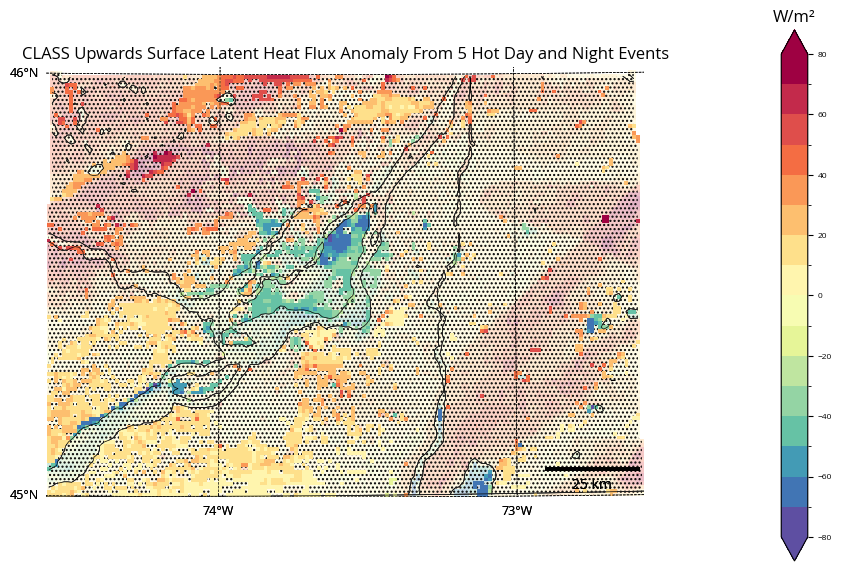

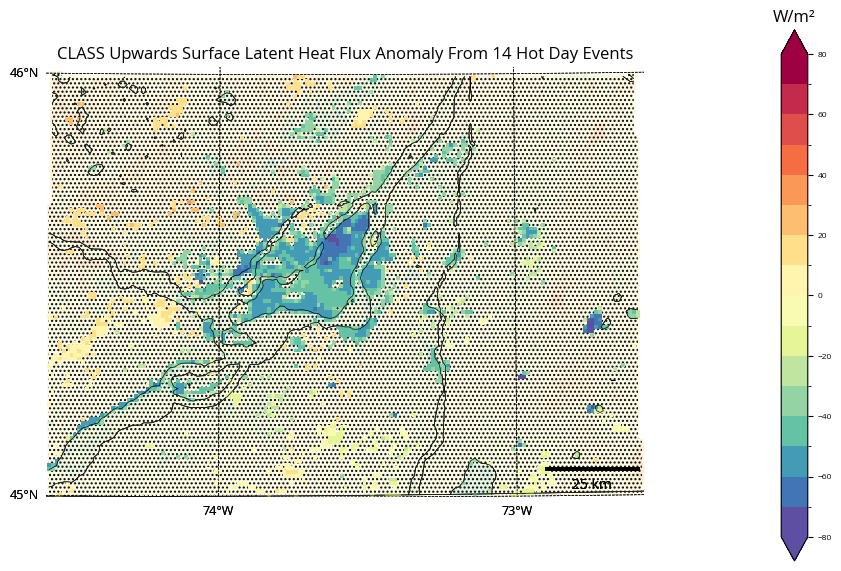

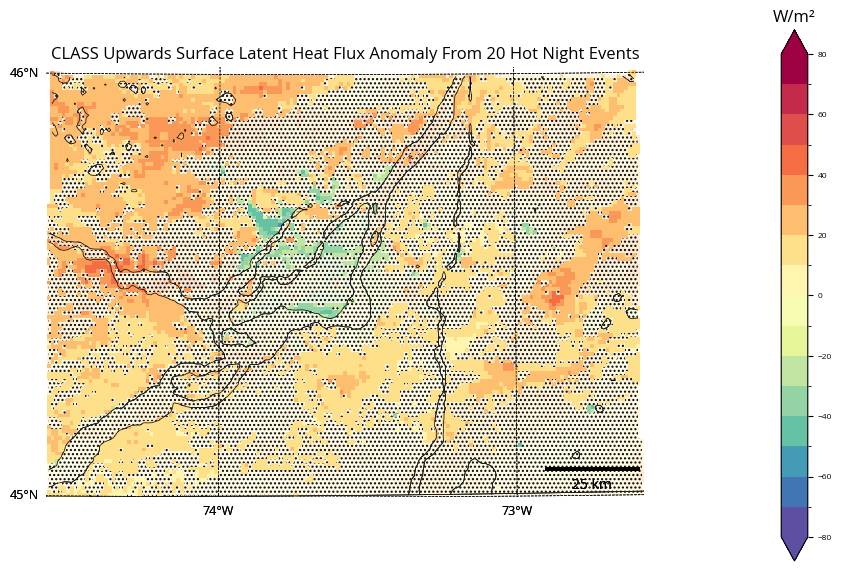

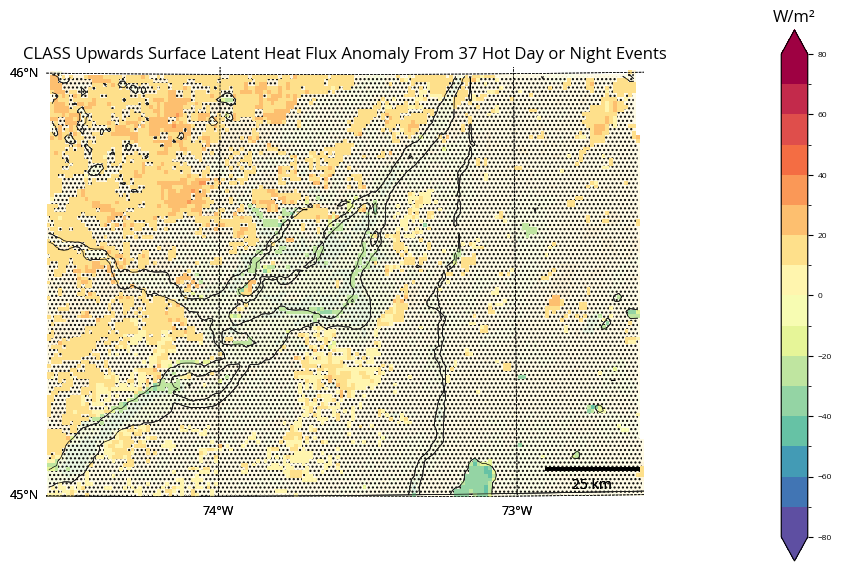

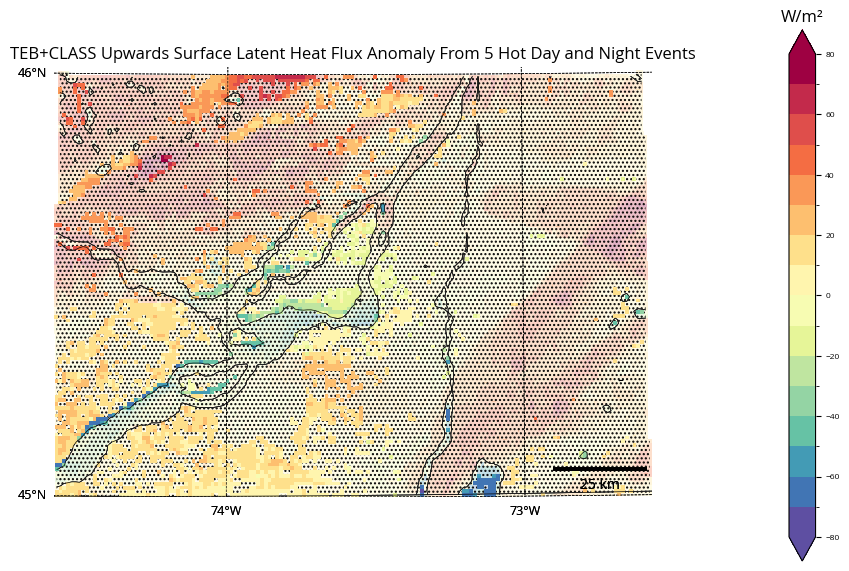

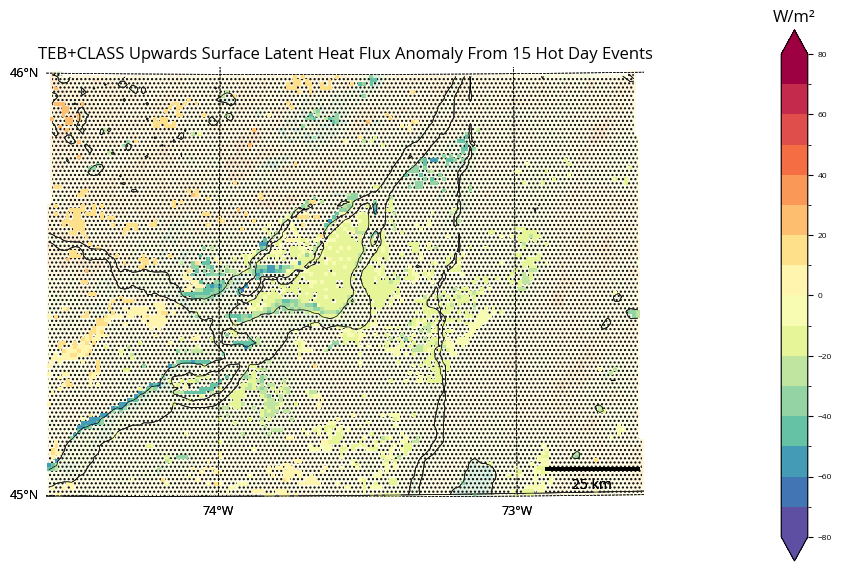

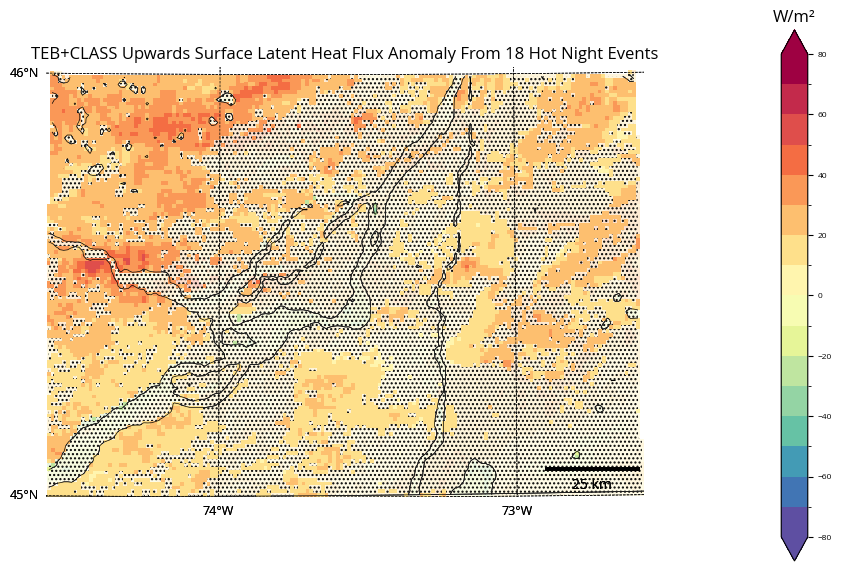

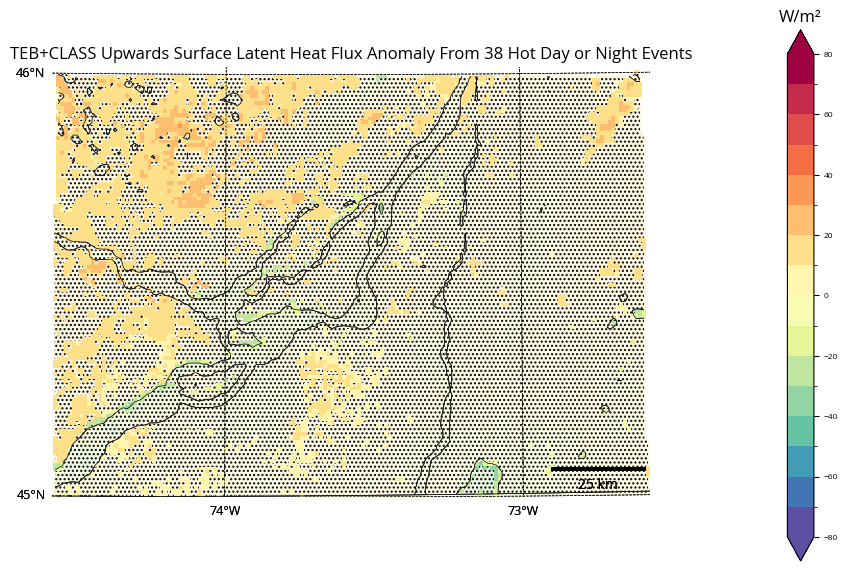

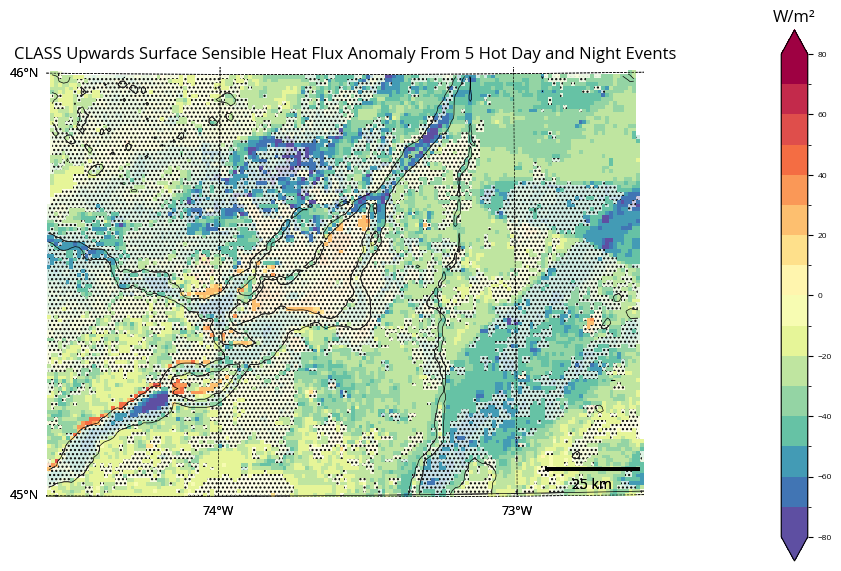

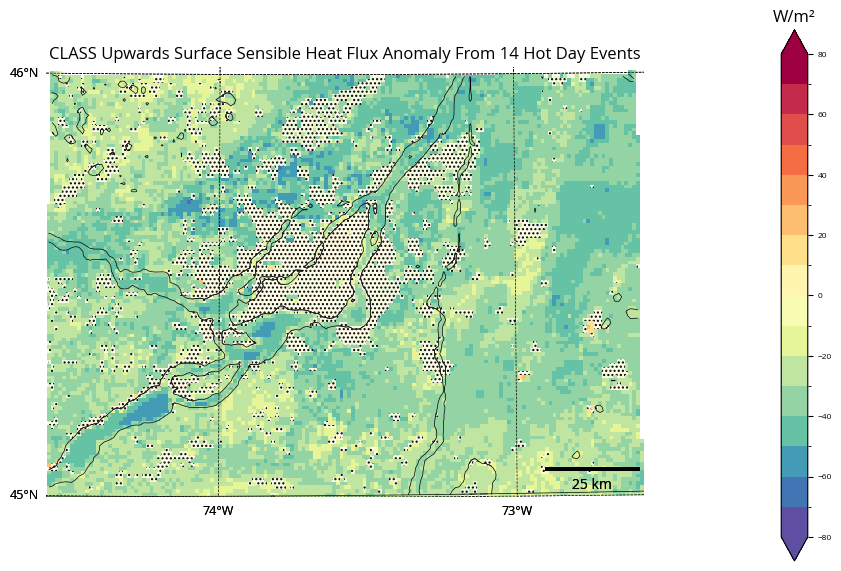

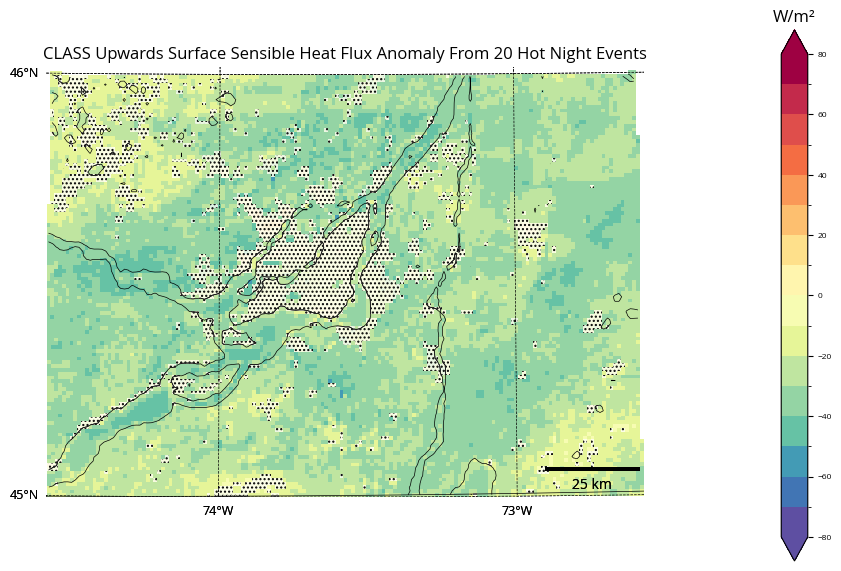

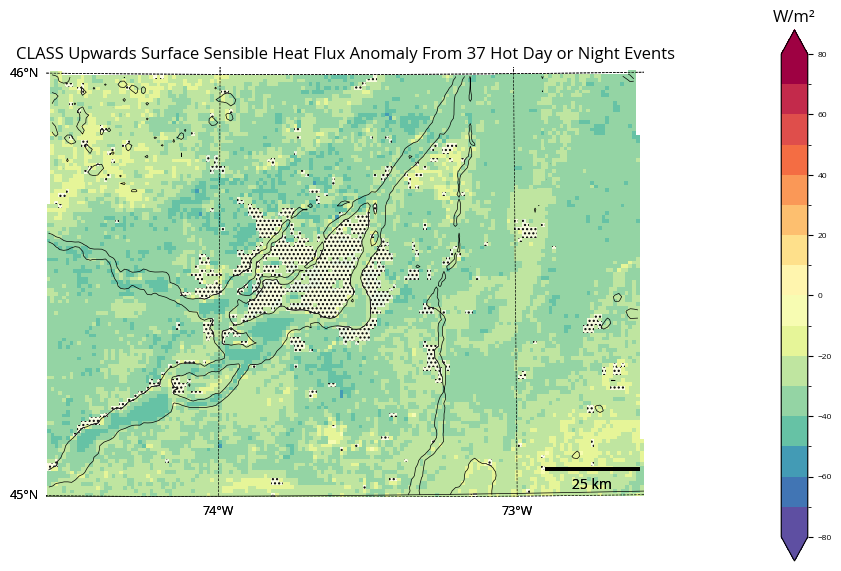

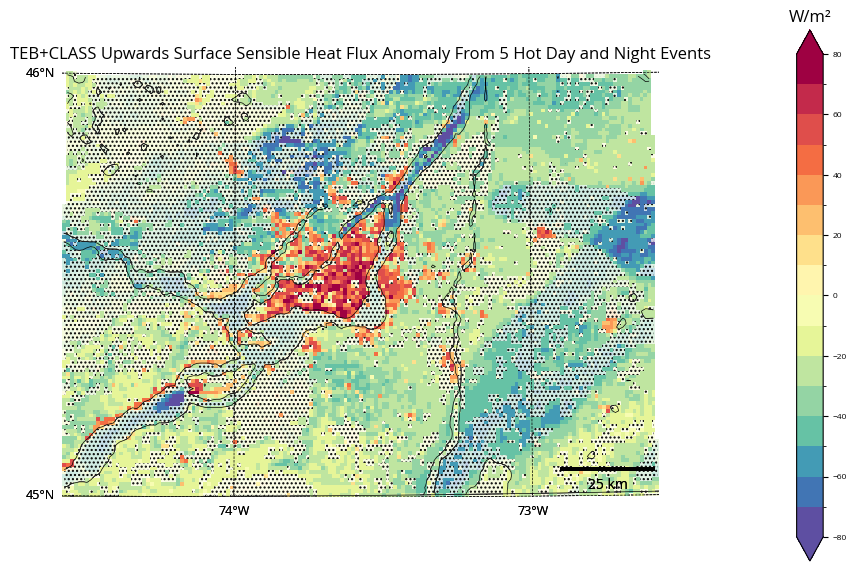

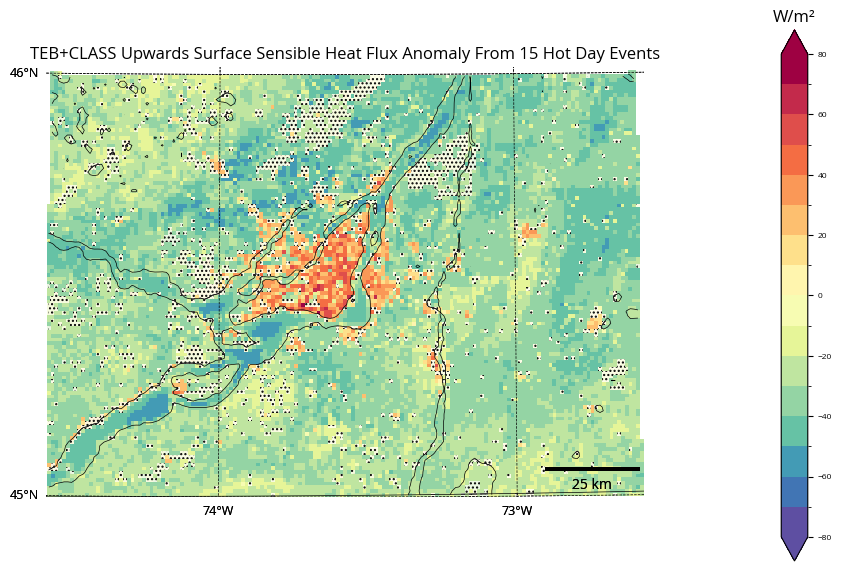

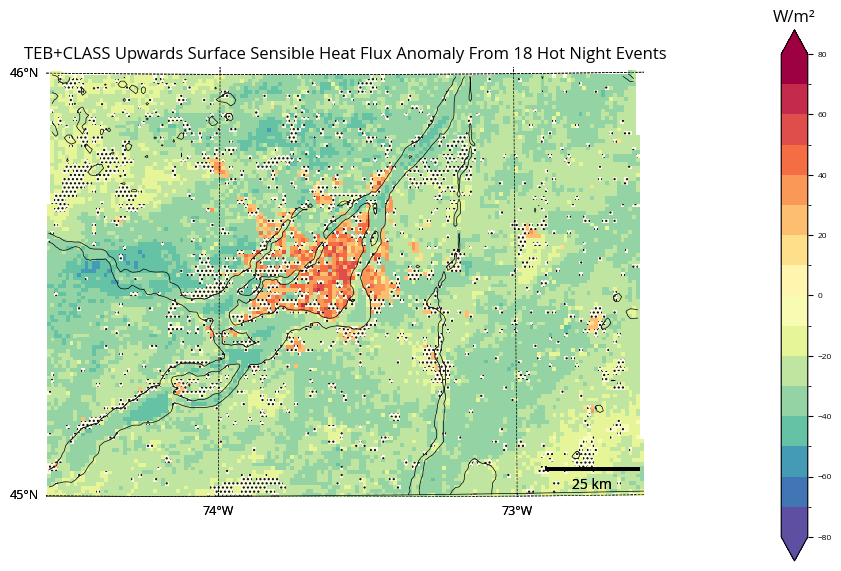

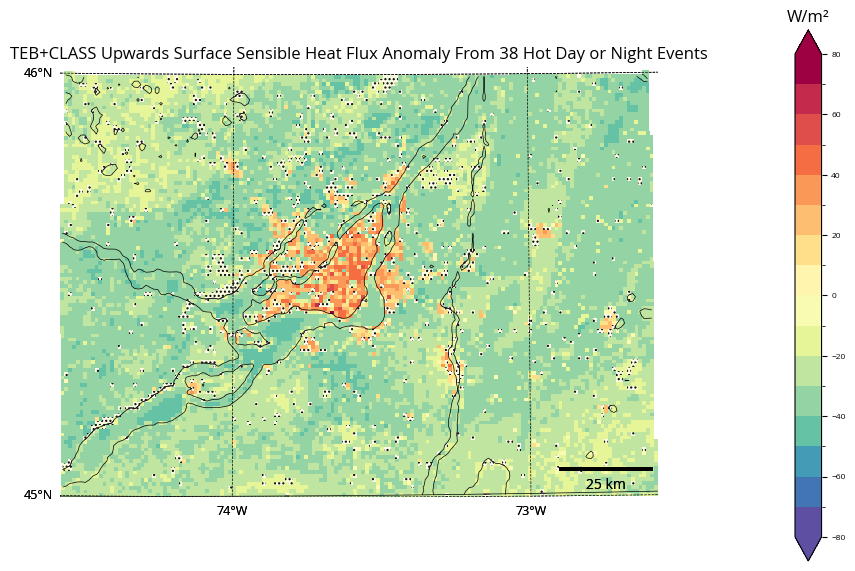

In [4]:
colorscale = 'Spectral_r'
vmin = -80
vmax =  80
units = 'W/m²'
num_levels = 16
hd_labels = ['Hot Day and Night','Hot Day', 'Hot Night','Hot Day or Night']
hd_file_labels = [hd_label.lower().replace(' ', '_') for hd_label in hd_labels]

for field, name, model, field_name in zip([latent_C, latent_T, sensible_C,sensible_T],
                                ['Upwards Surface Latent Heat Flux','Upwards Surface Latent Heat Flux', 'Upwards Surface Sensible Heat Flux','Upwards Surface Sensible Heat Flux'],
                                ['CLASS', 'TEB+CLASS']*2,
                                ['hfls_C', 'hfls_T', 'hfss_C', 'hfss_T']):
    m = field_name[-1] # T or C for TEB+CLASS or CLASS
    rhd = [extremes.where(extremes[f'tasmin_{m}'].notnull(),drop=True).where(extremes[f'tasmax_{m}'].notnull(),drop=True).time.values, # day AND night
           extremes.where(extremes[f'tasmax_{m}'].notnull(),drop = True).time.values, # day
           extremes.where(extremes[f'tasmin_{m}'].notnull(),drop=True).time.values, # night
           extremes.where(extremes.drop_vars([f'tasmin_{m}',f'tasmax_{m}']).notnull(),drop=True).time.values] # both

    for registered_heat_days,hd_label,hd_file_label in zip(rhd,hd_labels,hd_file_labels):
        gaps = np.diff(registered_heat_days).astype('timedelta64[D]').astype(int) 
        n_hd = (gaps >= 3).sum() + 1
        
        field_hd = field.sel(time=registered_heat_days)
        jja = field.groupby(['time.season','time.year']).mean(dim='time').sel(season='JJA')
        
        n_years = jja.sizes['year'] # Sampled jja's

        mean_hd = field_hd.mean(dim='time')
        std_hd  = field_hd.std(dim='time')

        mean_jja = jja.mean(dim='year')
        std_jja  = jja.std(dim='year')

        # Welch–Satterthwaite t-test from summary stats for unequal sample sizes
        result = stats.ttest_ind_from_stats(
            mean1=mean_hd, std1=std_hd, nobs1=n_hd,
            mean2=mean_jja, std2=std_jja, nobs2=n_years,
            equal_var=False
        )

        # Anomaly during hd versus jja average
        anomaly = mean_hd - mean_jja

        # Significant anomaly (where p_val < 0.05)
        sig_CI = anomaly.where(result.pvalue < alpha)
        
        # # Mask of values outside of 10-90th IPR
        # sig_IPR = anomaly.where((mean_hd<IPR.sel(quantile=0.1)) | (mean_hd> IPR.sel(quantile=0.9)))

        # Display map
        # Display the anomaly field, including insignificant
        fig, ax, cb1 = plot_field(anomaly, MTL_focus=True, vmin=vmin, vmax=vmax,cmap=colorscale,num_levels=num_levels,feature_colours='black',mesh_alpha=0.3,zorder=1)
        cb1.remove() # Remove supplementary colorbar

        # Display crosshatched layer over top of anomaly field where anomaly exists
        fig,ax, _ = plot_field(anomaly.notnull().astype(int), fig=fig,ax=ax,MTL_focus=True,hatch='....',zorder=2)

        # Display significant anomaly field, with transparent cells over top of crosshatched layer
        fig, ax, cb = plot_field(sig_CI, fig=fig,ax=ax,MTL_focus=True, vmin=vmin, vmax=vmax,cmap=colorscale,num_levels=num_levels,feature_colours='black',zorder=3)

        # Reposition colorbar
        pos = cb.ax.get_position()
        cb.ax.set_title(units)
        cb.ax.set_position([pos.x0+0.1, pos.y0+0.075, pos.width, pos.height*0.75])


        plt.title(f'{model} {name} Anomaly From {n_hd} {hd_label} Events')
        # plt.show()
        # plt.savefig(f'/runoff/gulley/UHI_plots/extreme_heat/fluxes/hd_anom_{hd_file_label}_{field_name}.png')
        plt.savefig(f'/runoff/gulley/UHI_plots/extreme_heat/fluxes/hd_anom_{hd_file_label}_{field_name}.png',dpi=300, bbox_inches = 'tight')

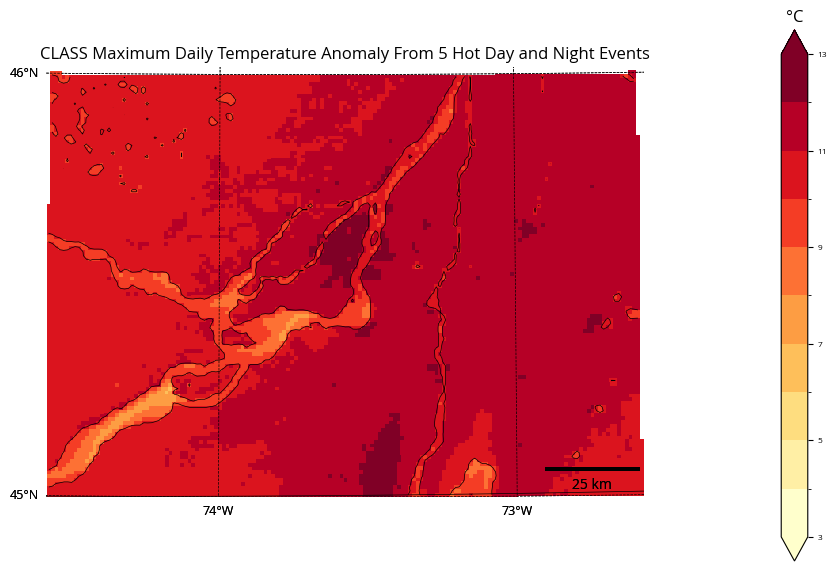

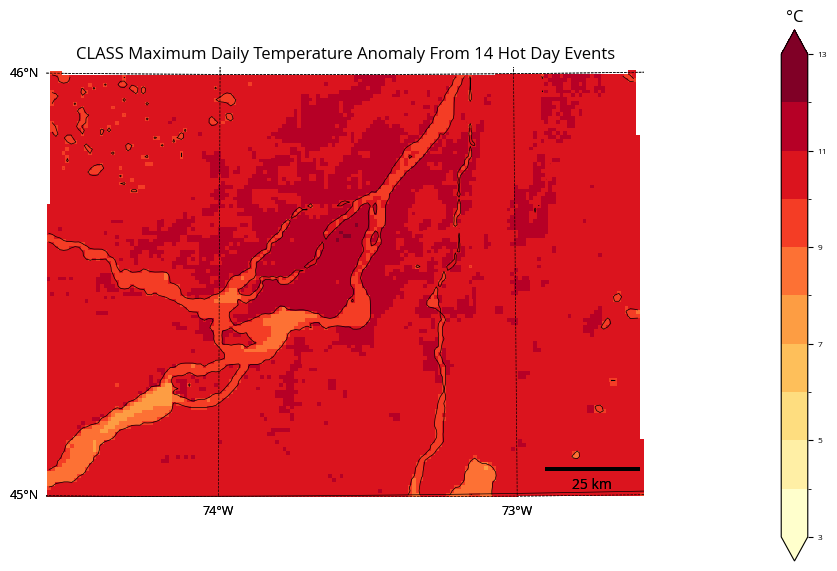

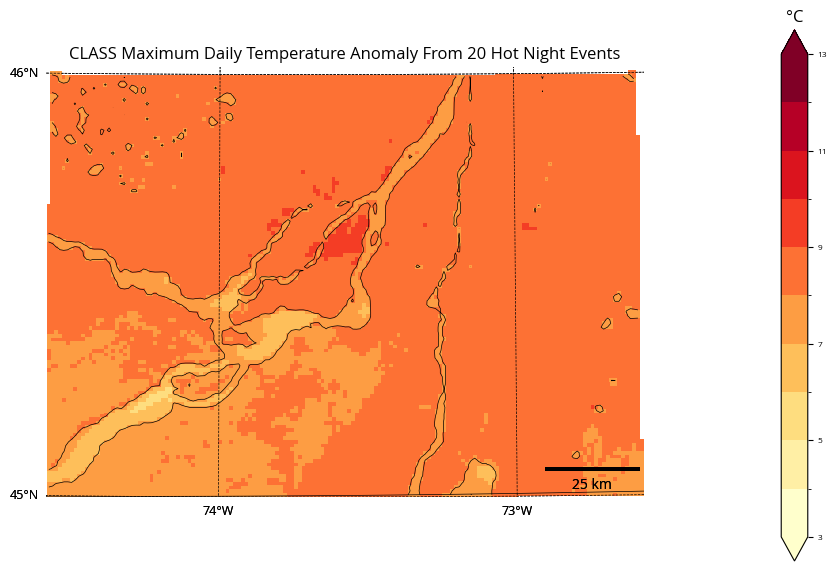

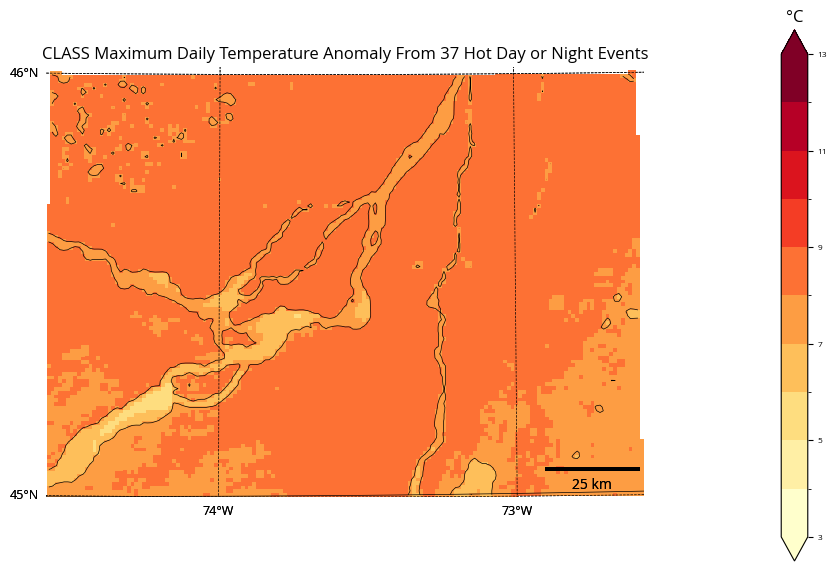

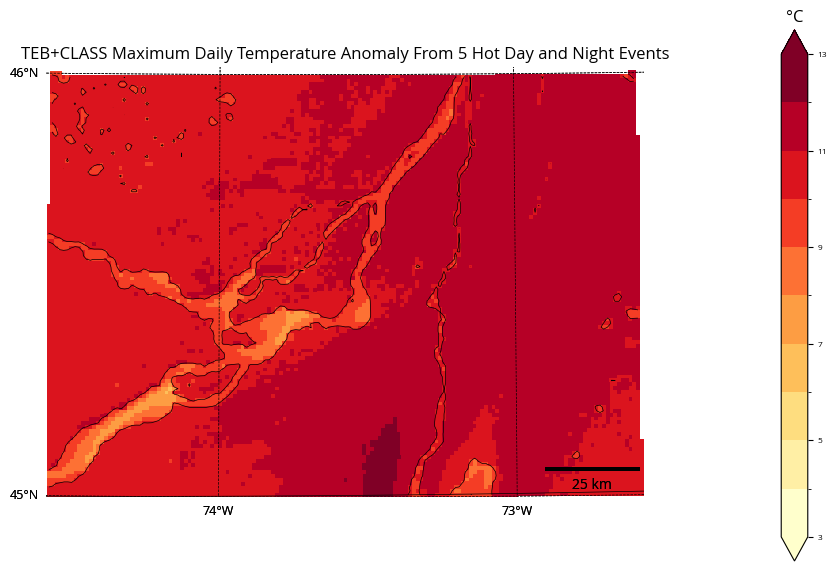

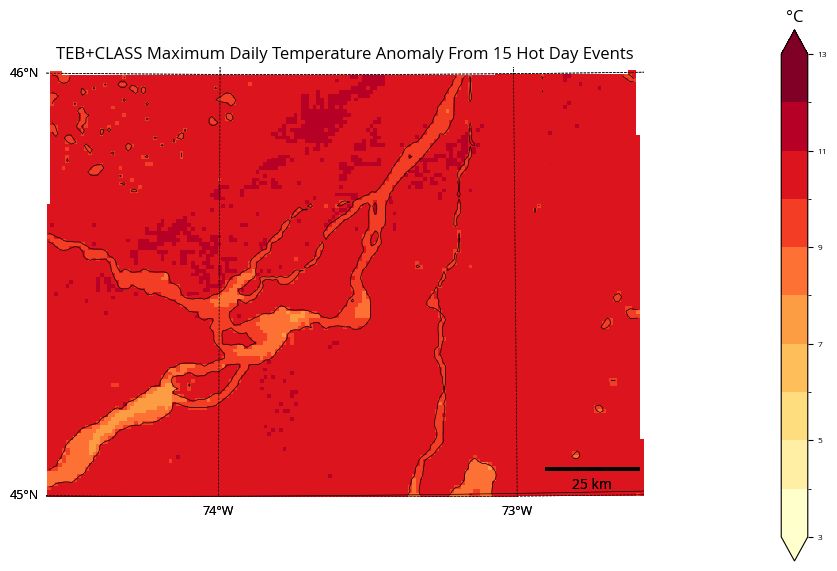

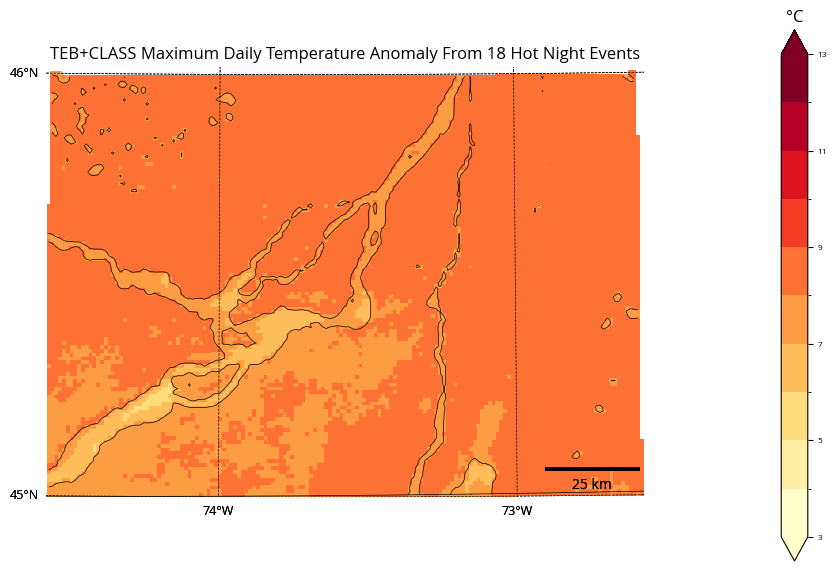

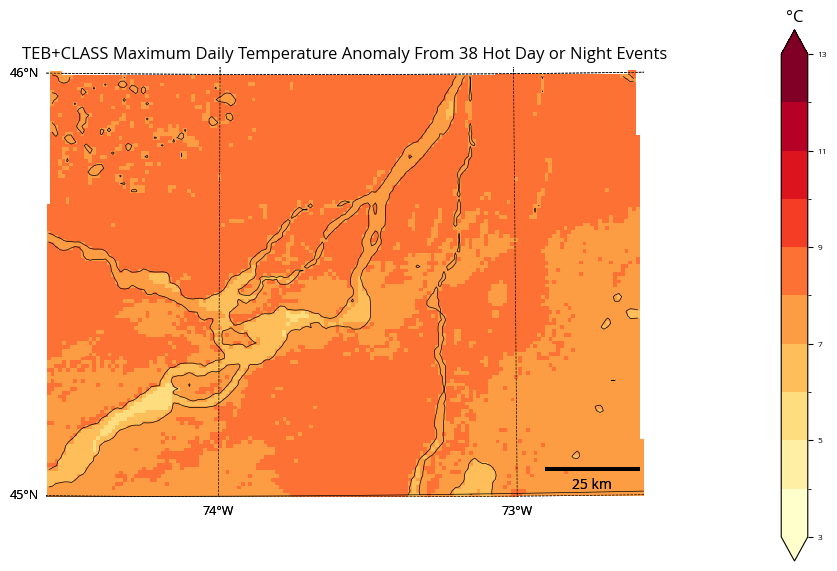

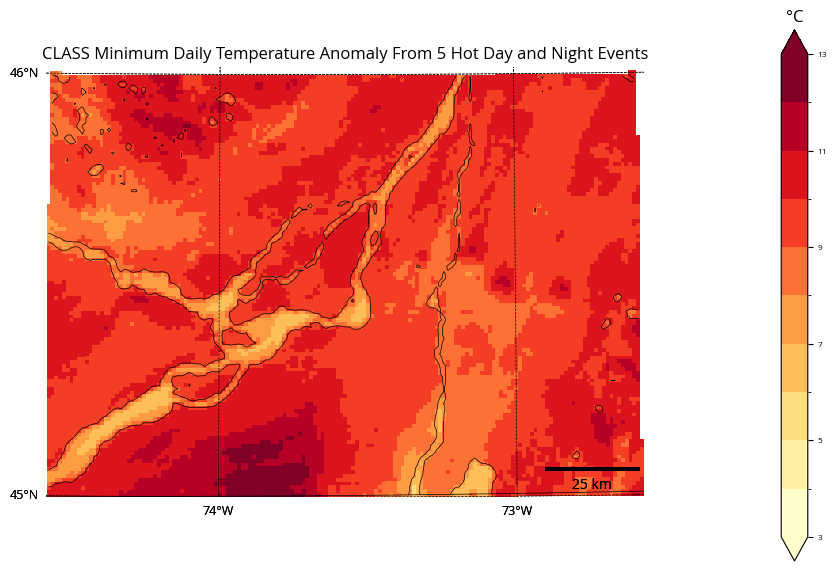

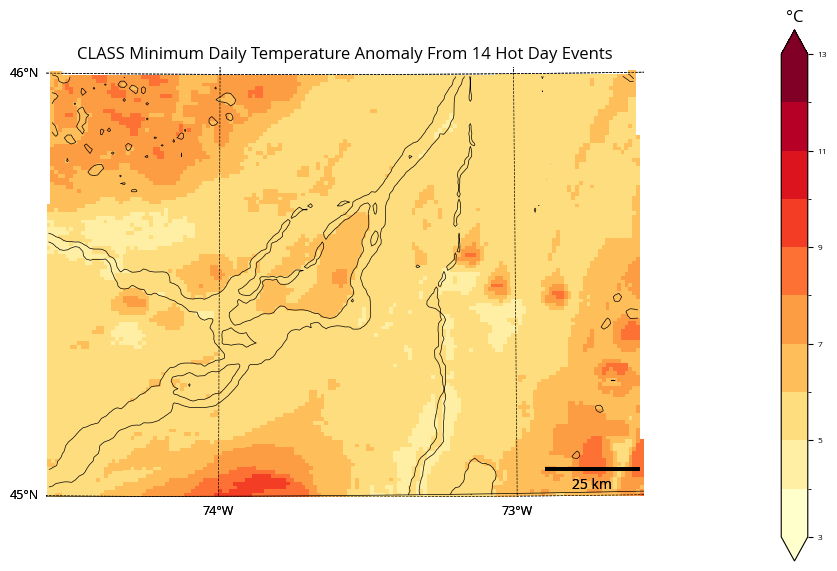

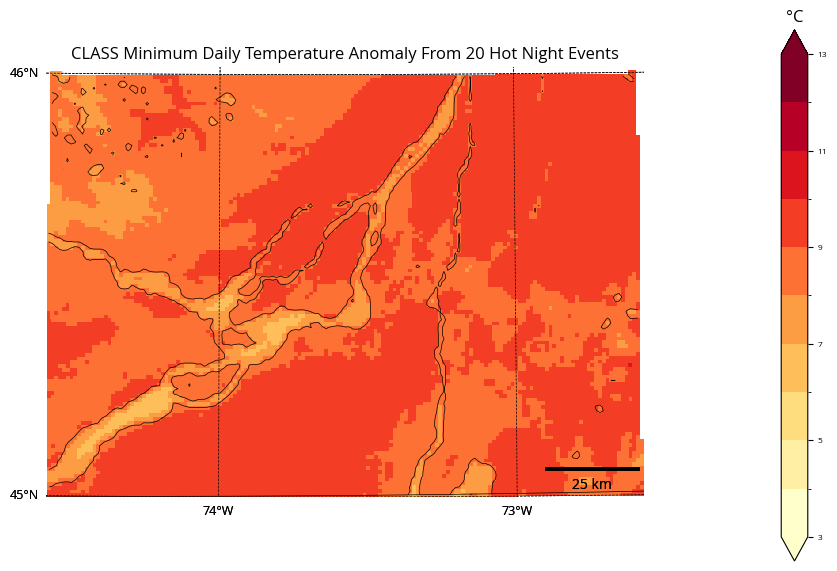

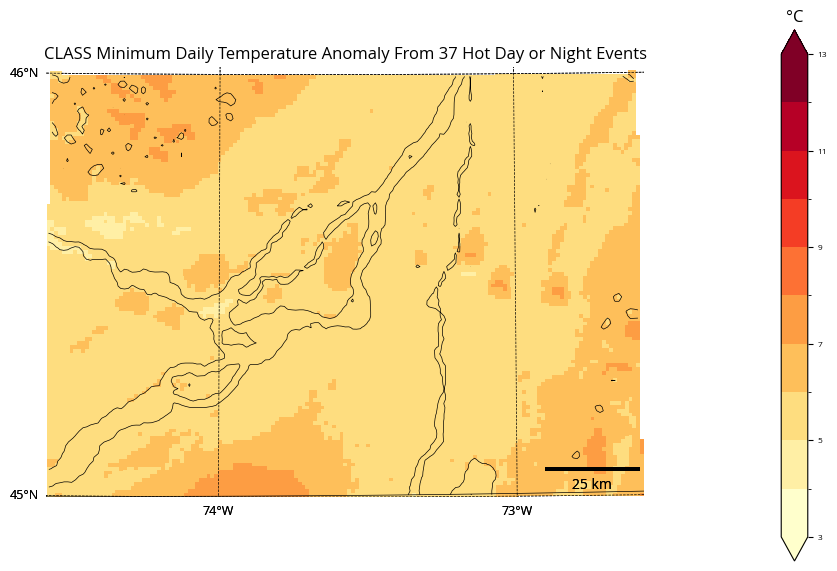

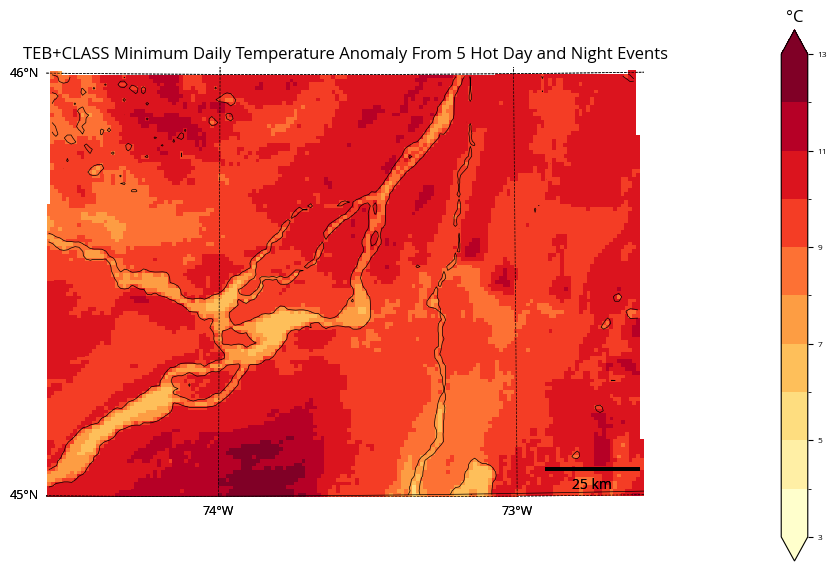

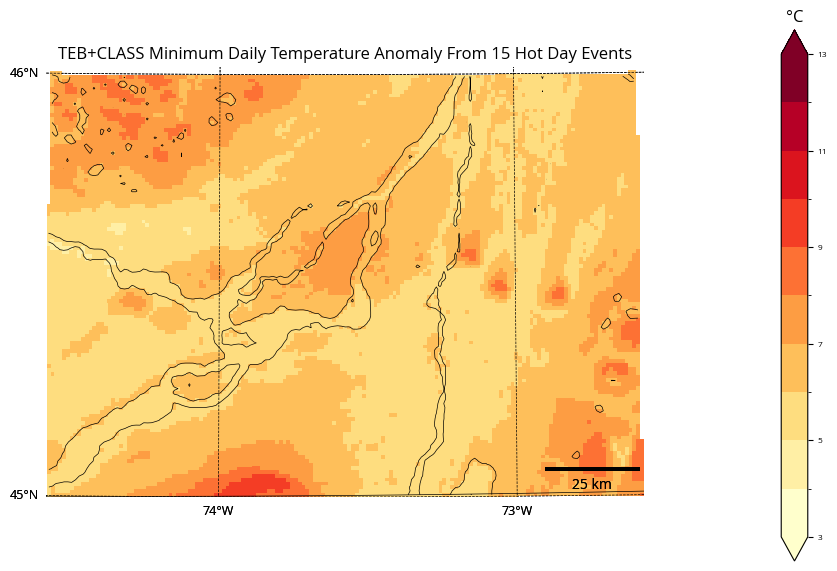

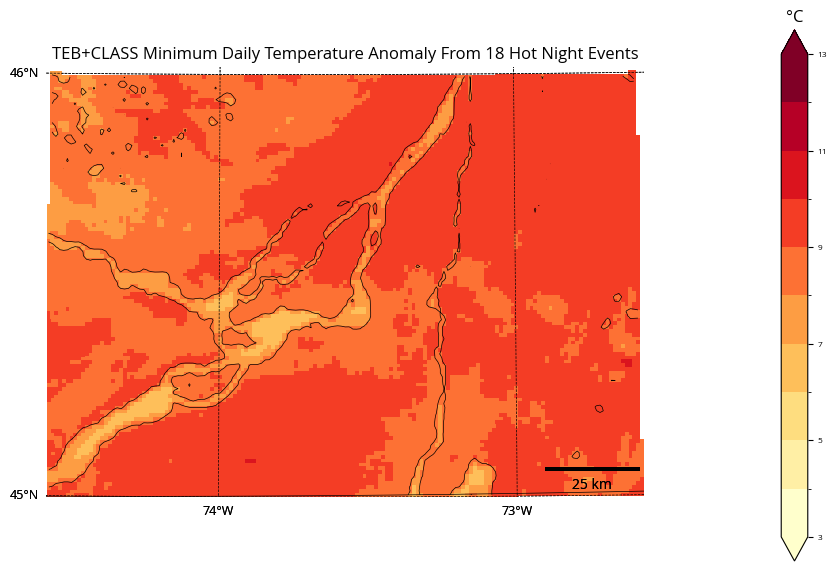

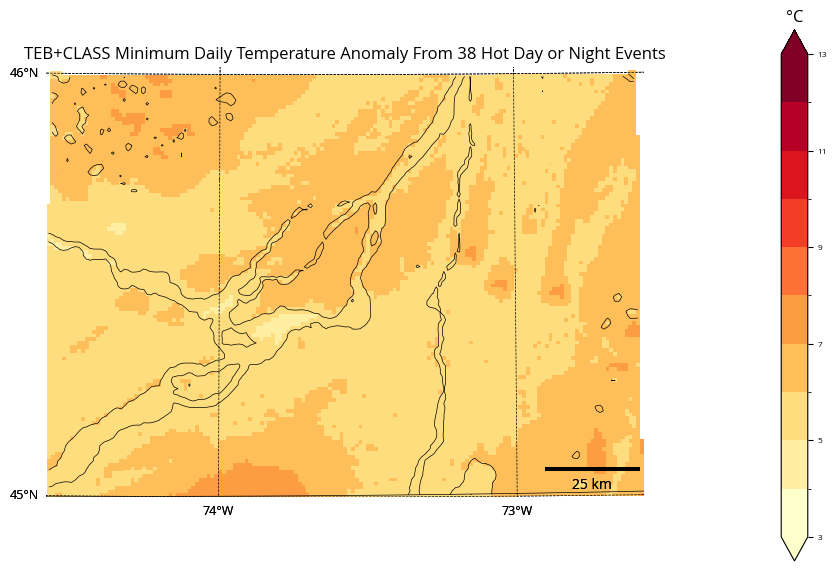

In [5]:
colorscale = 'YlOrRd'
vmin = 3
vmax = 13
units = '°C'
num_levels = 10
hd_labels = ['Hot Day and Night','Hot Day', 'Hot Night','Hot Day or Night']
hd_file_labels = [hd_label.lower().replace(' ', '_') for hd_label in hd_labels]

for field, name, model, field_name in zip([tasmax_C, tasmax_T, tasmin_C,tasmin_T],
                                ['Maximum Daily Temperature','Maximum Daily Temperature', 'Minimum Daily Temperature','Minimum Daily Temperature'],
                                ['CLASS', 'TEB+CLASS']*2,
                                ['tasmax_C', 'tasmax_T','tasmin_C', 'tasmin_T']):
    m = field_name[-1] # T or C for TEB+CLASS or CLASS
    rhd = [extremes.where(extremes[f'tasmin_{m}'].notnull(),drop=True).where(extremes[f'tasmax_{m}'].notnull(),drop=True).time.values, # day AND night
           extremes.where(extremes[f'tasmax_{m}'].notnull(),drop = True).time.values, # day
           extremes.where(extremes[f'tasmin_{m}'].notnull(),drop=True).time.values, # night
           extremes.where(extremes.drop_vars([f'tasmin_{m}',f'tasmax_{m}']).notnull(),drop=True).time.values] # both

    for registered_heat_days,hd_label,hd_file_label in zip(rhd,hd_labels,hd_file_labels):
        gaps = np.diff(registered_heat_days).astype('timedelta64[D]').astype(int) 
        n_hd = (gaps >= 3).sum() + 1
        
        field_hd = field.sel(time=registered_heat_days)
        jja = field.groupby(['time.season','time.year']).mean(dim='time').sel(season='JJA')
        
        n_years = jja.sizes['year'] # Sampled jja's

        mean_hd = field_hd.mean(dim='time')
        std_hd  = field_hd.std(dim='time')

        mean_jja = jja.mean(dim='year')
        std_jja  = jja.std(dim='year')

        # Welch–Satterthwaite t-test from summary stats for unequal sample sizes
        result = stats.ttest_ind_from_stats(
            mean1=mean_hd, std1=std_hd, nobs1=n_hd,
            mean2=mean_jja, std2=std_jja, nobs2=n_years,
            equal_var=False
        )

        # Anomaly during hd versus jja average
        anomaly = mean_hd - mean_jja

        # Significant anomaly (where p_val < 0.05)
        sig_CI = anomaly.where(result.pvalue < alpha)
        
        # # Mask of values outside of 10-90th IPR
        # sig_IPR = anomaly.where((mean_hd<IPR.sel(quantile=0.1)) | (mean_hd> IPR.sel(quantile=0.9)))

        # Display map
        # Display the anomaly field, including insignificant
        fig, ax, cb1 = plot_field(anomaly, MTL_focus=True, vmin=vmin, vmax=vmax,cmap=colorscale,num_levels=num_levels,feature_colours='black',mesh_alpha=0.3,zorder=1)
        cb1.remove() # Remove supplementary colorbar

        # Display crosshatched layer over top of anomaly field where anomaly exists
        fig,ax, _ = plot_field(anomaly.notnull().astype(int), fig=fig,ax=ax,MTL_focus=True,hatch='....',zorder=2)

        # Display significant anomaly field, with transparent cells over top of crosshatched layer
        fig, ax, cb = plot_field(sig_CI, fig=fig,ax=ax,MTL_focus=True, vmin=vmin, vmax=vmax,cmap=colorscale,num_levels=num_levels,feature_colours='black',zorder=3)

        # Reposition colorbar
        pos = cb.ax.get_position()
        cb.ax.set_title(units)
        cb.ax.set_position([pos.x0+0.1, pos.y0+0.075, pos.width, pos.height*0.75])


        plt.title(f'{model} {name} Anomaly From {n_hd} {hd_label} Events')
        # plt.show()
        plt.savefig(f'/runoff/gulley/UHI_plots/extreme_heat/temperatures/hd_anom_{hd_file_label}_{field_name}.png',dpi=300, bbox_inches = 'tight')

In [6]:
hd_file_labels

['hot_day_and_night', 'hot_day', 'hot_night', 'hot_day_or_night']